## Part 1

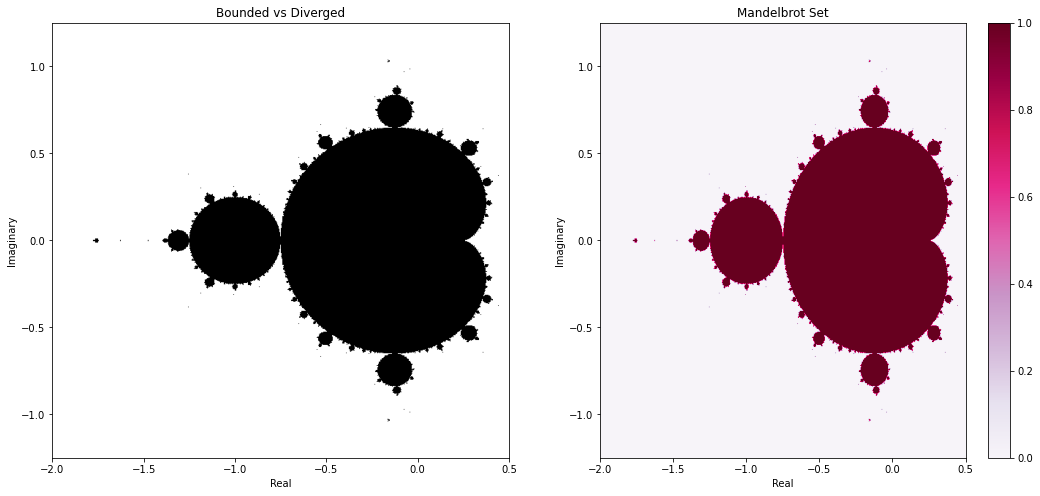

In [15]:
import part_1
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(18,8))

ax[0].imshow(part_1.boundary, extent=[-2,2,-2,2], origin='lower', cmap='binary', aspect='auto')

ax[0].set_xlabel("Real")
ax[0].set_ylabel("Imaginary")
ax[0].set_title("Bounded vs Diverged")
ax[0].set_xlim(-2,0.5)
ax[0].set_ylim(-1.25,1.25)

im = ax[1].imshow(part_1.boundary, extent=[-2,2,-2,2], origin='lower', cmap='PuRd', aspect='auto')

ax[1].set_xlabel("Real")
ax[1].set_ylabel("Imaginary")
ax[1].set_title("Mandelbrot Set")
ax[1].set_xlim(-2,0.5)
ax[1].set_ylim(-1.25,1.25)

fig.colorbar(im, ax=ax[1])

plt.show()

## Part 2: Plot 1

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def lorenz(t, W, sigma=10.0, r=28.0, b=8.0/3.0):
    """ 
    This function computes the time dervatives of each cordinate direction in 3D space

    Parameters
    ----------
    t : float - time
    
    W : list or numpy array - state vector of innitial coodinates - [X, Y, Z]
    
    sigma : float - Prandtl number
    
    r : float - Rayleigh number
    
    b : float - Dimensionless length parameter

    Returns
    -------
    list - elements are the time derivatives [dX/dt, dY/dt, dZ/dt].
    """

    X, Y, Z = W

    dXdt = -sigma * (X - Y)
    dYdt = r * X - Y - X * Z
    dZdt = -b * Z + X * Y

    return [dXdt, dYdt, dZdt]

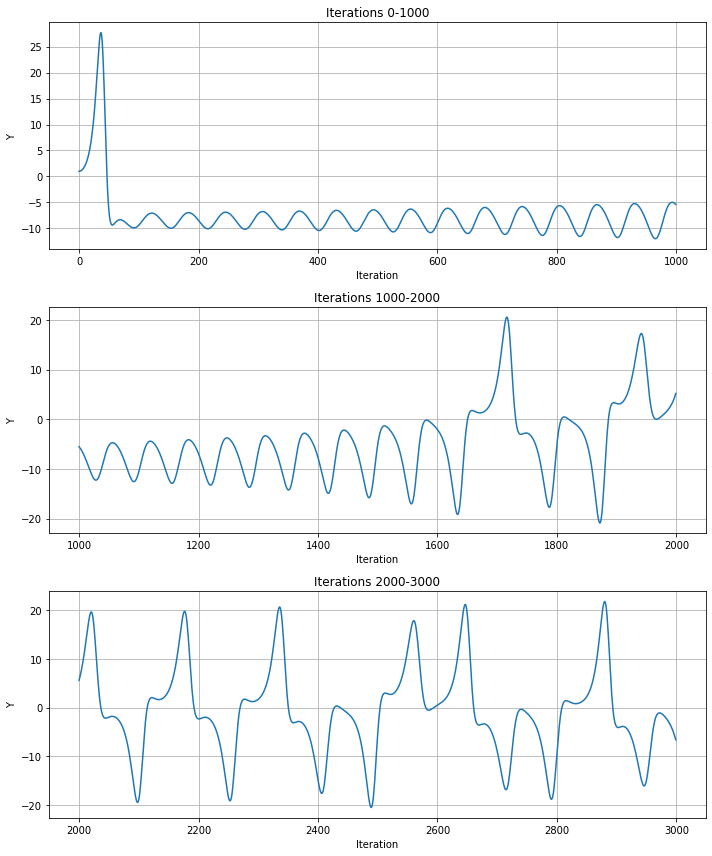

In [9]:
# init conditions
W0 = [0.0, 1.0, 0.0]

# time
t_span = (0, 30)

# Time values where solution is evaluated
t_eval = np.linspace(0, 30, 3000)

# solve it 
sol = solve_ivp(lorenz, t_span, W0, t_eval=t_eval)

# get solutions from returned list
t = sol.t
X = sol.y[0]
Y = sol.y[1]
Z = sol.y[2]

# plot it

fig, ax = plt.subplots(3, 1, figsize=(10,12))

ax[0].plot(np.arange(0,1000), Y[:1000])
ax[0].set_title("Iterations 0-1000")
ax[0].set_xlabel("Iteration")
ax[0].set_ylabel("Y")
ax[0].grid()

ax[1].plot(np.arange(1000,2000), Y[1000:2000])
ax[1].set_title("Iterations 1000-2000")
ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Y")
ax[1].grid()

ax[2].plot(np.arange(2000,3000), Y[2000:3000])
ax[2].set_title("Iterations 2000-3000")
ax[2].set_xlabel("Iteration")
ax[2].set_ylabel("Y")
ax[2].grid()

plt.tight_layout()

plt.show()

### Part 2: Plot 2

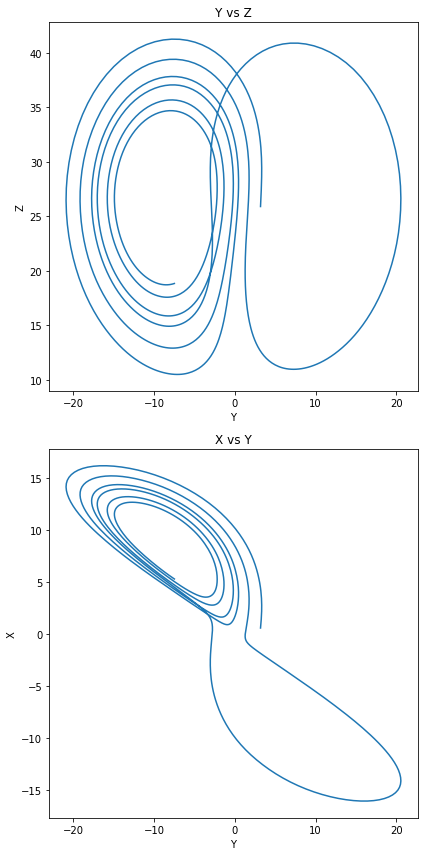

In [30]:

sol = solve_ivp(lorenz, (0, 30), W0, dense_output = True)

times = np.linspace(14, 19, 1000)

# solution evaluating at times
W = sol.sol(times)

X = W[0]
Y = W[1]
Z = W[2]

# plotting in phase space according to fig. 2
fig, ax = plt.subplots(2, 1, figsize=(6,12))


ax[0].plot(Y, Z)
ax[0].set_xlabel("Y")
ax[0].set_ylabel("Z")
ax[0].set_title("Y vs Z")


ax[1].plot(Y, -X)
ax[1].set_xlabel("Y")
ax[1].set_ylabel("X")
ax[1].set_title("X vs Y")



plt.tight_layout()
plt.show()

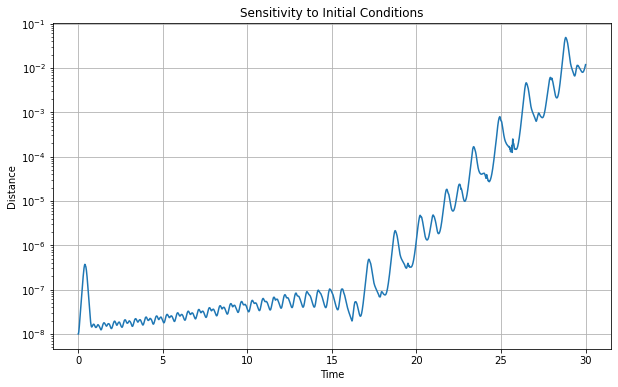

In [31]:

#give init. conditions a perturbation

dW = np.array([0.0, 1e-8, 0.0])
W0_p= np.array(W0) + dW

# solve both systems 

sol1 = solve_ivp(lorenz, (0, 30), W0, t_eval=t_eval)
sol2 = solve_ivp(lorenz, (0, 30), W0_p, t_eval=t_eval)

# distance
distance = np.sqrt((sol1.y[0] - sol2.y[0])**2 + (sol1.y[1] - sol2.y[1])**2 + (sol1.y[2] - sol2.y[2])**2)

# plot
plt.figure(figsize=(10,6))

plt.semilogy(t_eval, distance)

plt.xlabel("Time")
plt.ylabel("Distance")
plt.title("Sensitivity to Initial Conditions")

plt.grid()

plt.show()